In [11]:
import numpy as np
import os
import seaborn as sb
import pingouin as pg
import PcmPy as pcm
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt
from scipy.stats import ttest_1samp
from pathlib import Path
import sys
import SensoriMotorPrediction.globals as gl
from SensoriMotorPrediction.vis import plot_rdm

In [17]:
experiment = 'smp2'
glm = 13
H = 'L'
rois = gl.rois['ROI']
palette = ['#FFFF00', 'red', 'purple']

# Representation geometry during execution (Fig. 5b)

Mean crossnobis dissimilarity against 0 (one-sided t-test):
SMA: tval=3.955781492267649, pval=0.0008217553007728711
PMd: tval=4.594281239263784, pval=0.0002514500532052304
PMv: tval=5.416693275835404, pval=5.886512452060515e-05
M1: tval=4.652864565978087, pval=0.000226083776542447
S1: tval=4.129908690502404, pval=0.0005924529311408228
SPLa: tval=6.100549828404608, pval=1.8885144187223965e-05
SPLp: tval=5.069817144174073, pval=0.00010741463057058454


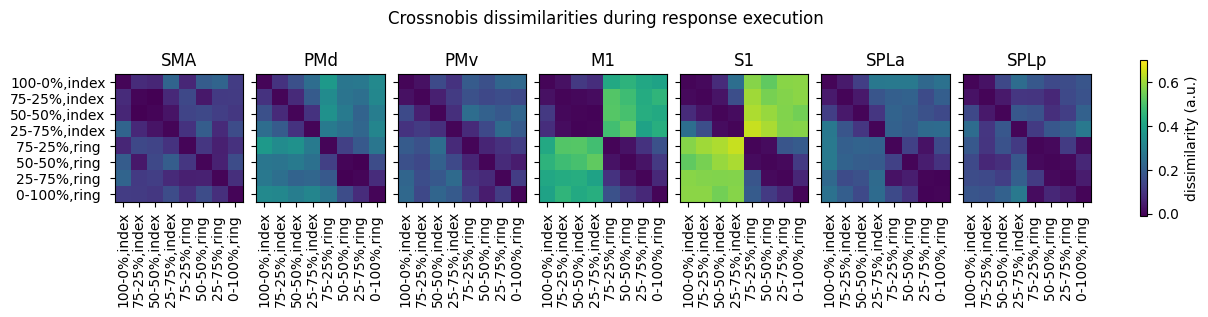

In [18]:
vmin, vmax = -.01, .7

fig, axs = plt.subplots(1, len(rois), figsize=(12, 3),sharex=True, sharey=True, constrained_layout=True)
print('Mean crossnobis dissimilarity against 0 (one-sided t-test):')
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_rdm(fig, axs, r, D, list(gl.regressor_mapping.keys())[5:], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

# log-Bayes factor for sensory input, expectation and surprise (Fig. 5c, see asterisks below bars)

In [14]:
df = pd.read_csv(os.path.join(ROOT, 'data', 'encoding', 'component_model.BOLD.tsv'), sep='\t')
df = df[(df['dataset']=='exec') & (df['Hem']==H)]
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='BF', hue='component', palette = palette, errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('log-Bayes factor')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor')
results = df.groupby(['roi', 'component']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
display(results)
plt.show()

NameError: name 'ROOT' is not defined

# Standardised weight of sensory input, expectation and surprise (Fig. 5c)

NameError: name 'df' is not defined

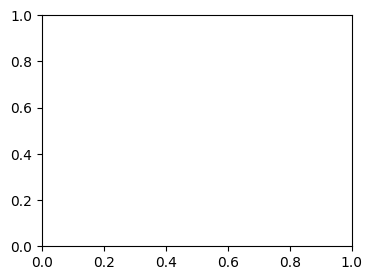

In [19]:
fig, ax = plt.subplots(figsize=(4, 3))
df['norm_weight'] = np.sqrt(df['weight']/ df['noise'])
sb.barplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', palette = palette, errorbar='se', estimator='mean')
sb.stripplot(ax=ax, data=df, x='roi', y='norm_weight', hue='component', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('weight')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
res = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id', alternative='less'))
display(res)
plt.show()

# Sensory input relative to sensory input+surprise in M1-S1 vs. premotor-parietal areas (Fig. 3e)


M1-S1 vs. premotor parietal (one-sided t-test): tval=12.162, pval=0.000


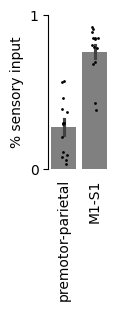

In [13]:
df_cluster = df.groupby(['cluster', 'participant_id', 'component']).mean(numeric_only=True).reset_index()
df_exp = df_cluster[df_cluster['component']=='sensory input']
df_sum = df_cluster.groupby(['cluster', 'participant_id']).sum(numeric_only=True).reset_index()
df_ratio = df_exp.copy()
df_ratio['ratio'] = df_exp['weight'].to_numpy() / df_sum['weight'].to_numpy()
df_ratio['cluster'] = pd.Categorical(df_ratio['cluster'], categories=['premotor-parietal','M1-S1'],ordered=True)

fig, ax = plt.subplots(figsize=(.8, 2))

sb.barplot(data=df_ratio, x='cluster', y='ratio', errorbar='se', color='grey')
sb.stripplot(data=df_ratio, x='cluster', y='ratio', size=2, color='black', jitter=.1, dodge=True, legend=False, order=['premotor-parietal','M1-S1'])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.tick_params(axis='x', bottom=False,)
ax.set_xlabel('')
ax.set_yticks((0, 1))
ax.set_xticklabels(['premotor-parietal', 'M1-S1'], rotation=90)
ax.set_ylabel('% sensory input')

m1_s1 = df_ratio[df_ratio['cluster']=='M1-S1'].ratio.to_numpy()
pmd_spl = df_ratio[df_ratio['cluster']=='premotor-parietal'].ratio.to_numpy()
tval, pval = ttest_1samp(m1_s1 - pmd_spl, popmean=0, alternative='greater')
print(f'M1-S1 vs. premotor parietal (one-sided t-test): tval={tval:.3f}, pval={pval:.3f}')
plt.show()